numpy matplotlib openpyxl pandas scipy intertools

In [122]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl
from itertools import product
from scipy.optimize import differential_evolution

In [123]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_пол, Tа_полн):
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = np.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = np.cbrt((G_в * n**2)/(np.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return np.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * np.sqrt(R_в * T)) / (β * P * q)

def β_k_def(k):
    β = np.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))
    return(β)

def c_p_def(P_poln_Pa, T1_poln_K):
    """
    Находит c_p:
    P_poln_Pa: Давление на входе в Паскалях (Pa)
    T1_poln_K: Температура на входе в Кельвинах (K)
    """
    # Перевод входного давления из Па в бары для сопоставления с таблицей
    P_poln_bar = P_poln_Pa / 1e5
    
    # Получаем список уникальных давлений из таблицы (они уже в барах)
    available_pressures = df['p_bar'].unique()
    
    # 2. Поиск самого близкого давления в барах
    closest_p = available_pressures[np.abs(available_pressures - P_poln_bar).argmin()]
    
    # Фильтруем данные для выбранной изобары
    data_p = df[df['p_bar'] == closest_p].sort_values('T_K')
    
    # 3. Линейная интерполяция по температуре
    # np.interp(целевая_T, список_T_из_таблицы, список_cp_из_таблицы)
    cp_value = np.interp(T1_poln_K, data_p['T_K'], data_p['c_p'])
    
    return cp_value

def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return np.array(x_result), np.array(y_result)

def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    """
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()
    """

In [124]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

"""
plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()
"""

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [125]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [126]:
"""
d1_отн_start = 0.3
d1_отн_end = 0.6
c_а1_отн_start = 0.45
c_а1_отн_end = 0.65
с_а_отн_start = 0.45
с_а_отн_end = 0.55
Hт_ср_отн_start = 0.1
Hт_ср_отн_end = 0.4
H_т1_start = 0.15
H_т1_end = 0.25
D_type = ['D_к_const', 'D_вт_const', 'D_ср_const']
"""

"\nd1_отн_start = 0.3\nd1_отн_end = 0.6\nc_а1_отн_start = 0.45\nc_а1_отн_end = 0.65\nс_а_отн_start = 0.45\nс_а_отн_end = 0.55\nHт_ср_отн_start = 0.1\nHт_ср_отн_end = 0.4\nH_т1_start = 0.15\nH_т1_end = 0.25\nD_type = ['D_к_const', 'D_вт_const', 'D_ср_const']\n"

In [127]:
import numpy as np
from scipy.optimize import differential_evolution

# ================================
# Параметры поиска
# ================================
bounds = [
    (0.3, 0.6),   # d1_отн
    (0.45, 0.65), # c_а1_отн
    (0.45, 0.55), # c_a2_отн
    (0.1, 0.4),   # Hт_ср_отн
    (0.15, 0.25), # H_т1
    (0.5, 0.5)    # R_ср1
]

D_types = ['D_к_const', 'D_вт_const', 'D_ср_const']

In [128]:
# ================================
# 3. МОДЕЛЬ (ВСТАВЬ СЮДА СВОЙ КОД)
# ================================
def model(params, D_type):
    
    # Условие!!!
    Tа_полн = 288   # K
    Pа_полн = 1.013 * 10**5  # Па
    G_в = 58.7  # кг/с
    π_к_полн = 18.2  # Степень повышения давления в компрессоре
    n = 8600  # об/мин

    R_в = 287.4  # Дж/(кг*К)
    k = 1.4  # показатель адиабаты для воздуха
    # Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
    c_p = 1006

    n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
    # Условие!!!

    d1_отн, c_а1_отн, c_a2_отн, Hт_ср_отн, H_т1, R_ср1 = params
    # 1. Импорт и очистка данных
    # skipinitialspace=True убирает пробелы после запятых в CSV
    df = pd.read_csv('resources/air_param.csv', skipinitialspace=True)

    # Очищаем названия колонок от случайных пробелов
    df.columns = df.columns.str.strip()

    # Принудительно переводим важные колонки в числа. 
    # Ошибки (буквы) станут NaN, которые мы потом удалим.
    cols_to_fix = ['p_bar', 'T_K', 'c_p']
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df = df.dropna(subset=cols_to_fix)



    # Определим адиабатический КПД
    η_пол = 0.90 # Политропический КПД компрессора из рис.1

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    #  Ожидаемый КПД
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    π_к_полн_0 = π_к_полн
    η_к_полн_0 = η_к_полн

    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
    T2_полн = Tk_полн

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k, R_в, Tk_полн)

    # Плотность рабочего тела по заторможенным параметрам
    ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

    # Окружная скорость реальная на конце лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)
    ε_вых = ε_gdf(k, λ_вых)

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)


    π_ла_полн = π_к_полн / (σ_вх * σ_вых)
    η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)

    π_ла_полн_0 = π_ла_полн
    η_ла_полн_0 = η_ла_полн


    U_k1_before = U_k1 * 100
    number = 1
    while True:
        # Осевая скорость на переферии РК
        c_а1 = c_real_def(U_k1, c_а1_отн)
        
        # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
        c_вх = c_real_def(U_k1, c_а1_отн)
        c_вых = c_real_def(U_k1, c_a2_отн)

        # Пренебрегая теплообменом в трубках:
        T1_полн = Tа_полн


        # Температура на выходе из ЛА компрессора
        Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
        T2_полн = Tk_полн

        # Критическая скорость звука во входном и выходном патрубках
        a_кр_вх = a_кр_def(k, R_в, Tа_полн)
        a_кр_вых = a_кр_def(k, R_в, Tk_полн)

        # Приведенные скорости в данных сечениях
        λ_вх = λ_def(c_вх, a_кр_вх)
        λ_вых = λ_def(c_вых, a_кр_вых)

        # Коэффициент потерь полного давления во входном и выходном патрубках
        ξ_вх = 0.05     # Для входного патрубка
        ξ_вых = 0.15    # Для выходного патрубка

        # ГДФ плотности для входного и выходного патрубков
        ε_вх = ε_gdf(k, λ_вх)       
        ε_вых = ε_gdf(k, λ_вых)
        #  !!!!!!!!Перепроверить верность выражений в функции!

        # Коэффициенты сохранения полного давления во входном и выходном патрубках
        σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
        σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

        # Полные давления на входе и выходе из лопаточного аппарата
        P1_полн = σ_вх * Pа_полн
        Pк_полн = Pа_полн * π_к_полн
        P2_полн = Pк_полн / σ_вых
        # Средний радиус на входе в первую степень
        r_ср1_отн = radius_отн(d1_отн)

        # Безразмерная окружная составляющая абсолютной скорости на входе
        c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

        # Абсолютная скорость: 
        c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

        # Приведенная скорость:
        λ1 = λ_def(c1, a_кр_вх)

        # ГДФ плотности
        ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))
        # !!!!!!!!Перепроверить верность выражения!!!!!!!

        # Плотность рабочего тела перед РК
        ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
        # !!!!!!!!Перепроверить верность выражения!!!!!!!

        # Перерасчет окружной скорости конца рабочей лопатки
        U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
        loss_percenteg = 0.00001
        # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
        if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
            break
        else:
            U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
            number = number + 1 # Подсчет числа итераций
        

    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)
    ε_вых = ε_gdf(k, λ_вых)

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн
    P2_полн = Pа_полн * π_к_полн / σ_вых

    # Степень повышения полного давления лопаточного аппарата
    π_ла_полн = P2_полн / P1_полн
    π_к_полн = π_ла_полн * (σ_вых * σ_вх)

    # КПД лопаточного аппарата
    η_ла = σ_вых * σ_вх  # Должно быть 1

    # Коэффициент C определяется из графика на рис. 7
    C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
    # !!!!!!!!
    # !!!!!!!!

    η_ла_полн = η_к_полн / C
    η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


    β = β_k_def(k)

    # Приведенная плотность потока массы
    q_вх = q_gdf(k, λ_вх)
    q_вых = q_gdf(k, λ_вых)
    # Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
    F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
    F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)



    # Наружный диаметр ротора:
    D_к1 = 2 * U_k1 / n

    # Внутренний диаметр
    D_вт1 = D_к1 * d1_отн

    # Средний диаметр
    D_ср1 = D_к1 * r_ср1_отн

    # Высота лопатки РК 1-й ступени:
    h_1 = (1/2) * D_к1 * (1 - d1_отн)


    # Выбор формы проточной части лопаточного аппарата. 

    if D_type == 'D_к_const':
        # Dк = const

        D_к = D_к1
        # Диаметр втулки лопаток последнйей ступени:
        D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
        # Относительный диаметр втулки рабочего колеса последней ступени:
        d_n_отн = D_вт_n / D_к
        h_n = (1/2) * D_к * (1 - d_n_отн)

    elif D_type == 'D_вт_const':
        # Dвт = const

        D_вт = D_вт1
        D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
        d_n_отн = D_вт / D_к_n
        h_n = (1/2) * (D_к_n - D_вт)

    else:
        # Dср = const
        
        D_ср = D_ср1
        D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
        D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
        h_n = (1/2)*(D_к_n - D_вт_n)
        d_n_отн = d1_отн


    # Окружная скорость концов рабочих лопаток "средней" ступени:
    ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
    U_к_ср = (U_k1 + U_k2) / 2
    # Теоретический напор "средней" ступени:
    Hт_ср = Hт_ср_отн * (U_к_ср**2)

    # Адиабатический напор компрессора по параметрам затарможенного потока
    H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

    # Сумма теоретических напоров по ступеням:
    H_тк = H_ад_к_полн / η_к_полн

    # Число ступеней компрессора:
    z = H_тк / Hт_ср
    z = math.ceil(z)

    N = z   # Число ступеней компрессора
    N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

    Hт_x_i_отн = []
    Hт_i_отн = []

    c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени


    Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
    η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)


    R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
    Kh_i = np.concatenate([
        np.linspace(0.99, 0.94, 6),
        np.full((N-6), 0.94)
    ])

    plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода")
    plot_results(N_list, η_ад_полн_i, "Относительный КПД")
    plot_results(N_list, Hт_i_отн, "Относительный теоретический напор")
    plot_results(N_list, R_ср1_list, "Степень реактивности")
    plot_results(N_list, Kh_i, "Поправочный коэффициент")


    # Расчет ВНА
    # Коэффициент сохранения полного давления в ВНА
    # Направление абсолютной скорости на входе в ВНА
    α_1_вна = math.radians(90)
    α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

    # 3. Поступенчатый расчет значений для каждой ступени

    # Коэффициент расхода на выходе из ступени
    c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]]))

    # Давление перед ступенями по длине компрессора
    P1_полн_i = np.linspace(P1_полн, P2_полн, N)

    # Температура перед ступенью по длине компрессора
    T1_полн_i = np.linspace(T1_полн, T2_полн, N)

    # Диаметры относительные по длине компрессора
    d1_отн_i = np.linspace(d1_отн, d_n_отн, N)

    # Окружные скорости по длине компрессора
    U_k_i = np.linspace(U_k1, U_k2, N)

    # Начало расчета из Бекнева
    # 1. Теоретический напор для i-й ступени:
    Hт_i = Hт_i_отн * (U_k_i**2)

    # 2. Действительная работа сжатия для i-й ступени:
    L_z_i = Kh_i * Hт_i

    # 3. Адиабатическая работа сжатия для i-й ступени:
    H_ад_i = L_z_i * η_ад_полн_i

    # Генерация списка c_p для каждой ступени
    # Расчет списка c_p
    try:
        c_p_i = [c_p_def(p, t) * 1000 for p, t in zip(P1_полн_i, T1_полн_i)]
    except Exception as e:
        print(f"Произошла ошибка при расчете: {e}")
        
    # 4. Повышение полной температуры в ступени:
    ΔT_полн_i = L_z_i / c_p_i # с_р в каждой ступени разный т.к. меняется температура

    # 5. Полная температура на выходе из ступени:
    T3_полн_i = T1_полн_i + ΔT_полн_i
    T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень

    # 6. Степень повышения полного давления:
    π_полн_i = (1 + (H_ад_i / (c_p * T1_полн_i)))**(k/(k-1))
    
    # 7. Полное давление на выходе из ступени:
    P3_полн_i = P1_полн_i * π_полн_i 
    P1_полн_i_plus_1 = P3_полн_i
        
    # 8. Критическая скорость потока на входе и выходе:
    a_кр_1_i = np.sqrt((2*k/(k+1))*R_в*T1_полн_i)
    a_кр_3_i = np.sqrt((2*k/(k+1))*R_в*T3_полн_i)
        
    # 9. Средний радиус на входе в i-ю ступень:
    r_ср1_отн_i = np.sqrt( (1 + d1_отн_i**2) / 2)
        
    # 10. Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
    c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1) - (Hт_i_отн / (2 * r_ср1_отн_i))
        
    # 11. Направление абсолютной скорости на входе
    α_1_i = np.arctan(c_a_i_отн / c_u1_отн_i)
        
    # 12. Приведенная скорость на входе
    c_a1_i = c_a_i_отн * U_k_i
    λ_1_i = c_a1_i / (np.sin(α_1_i) * a_кр_1_i)
        
    # 13. ГДФ расхода
    q_1_i = q_gdf(k, λ_1_i)

    # 14. Кольцевая площадь на входе в ступень
    F_1_i = (G_в * np.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * np.sin(α_1_i))

    # 15. Кольцевая площадь на выходе из ступени F3
    c_a3_отн_i = c_a_i_отн_plus_1
    c_a3_i = c_a3_отн_i * U_k_i
    λ_3_i_0 = c_a3_i / (np.sin(α_1_i) * a_кр_3_i)

    q_3_i = q_gdf(k, λ_3_i_0)
    F_3_i_0 = F_1_i * ((q_1_i * P1_полн_i) / (q_3_i * P3_полн_i)) * np.sqrt(T3_полн_i / T1_полн_i)
        
    # 16. Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
    if D_type == 'D_к_const':
        D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i_0) / np.pi))
        d3_отн_i_0 = D_вт3_i / D_к1
    elif D_type == 'D_вт_const':
        D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i_0)/ np.pi))
        d3_отн_i_0 = D_вт / D_к3_i
    else:
        d3_отн_i_0 = np.linspace(d1_отн, d1_отн, N)

    # Относительный средний радиус на выходе из ступени
    r_ср3_отн_i = np.sqrt( (1 + d3_отн_i_0**2) / 2)

    # 17. Безразмерная окружная состовляющая абсолютной скорости на выходе
    R_ср1_i_plus_1 = np.concatenate((R_ср1_list[1:], [R_ср1_list[-1]]))
    Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [Hт_i_отн[-1]]))

    c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_i_plus_1) - (Hт_i_отн / (2 * r_ср3_отн_i))

    # 18. Направление потока в абсолютном движении после НА
    α_3_i = np.atan(c_a3_отн_i / c_3u_отн_i)

    # 19. Приведенная скорость на выходе
    λ_3_i = c_a3_i / (np.sin(α_3_i) * a_кр_3_i)

    # 20. Действительная кольцевая площадь на выходе из ступени
    F_3_i = F_3_i_0 * ((q_gdf(k, λ_3_i_0)) / (q_gdf(k, λ_3_i)))
    F_1_i_plis_1 = np.concatenate((F_3_i[1:], [F_3_i[-1]]))

    # 21. Действительный относительный диаметр втулки d_3_отн подсчитывется в завис от типа проточн части.
    if D_type == 'D_к_const':
        D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
        d3_отн_i = D_вт3_i / D_к1
    elif D_type == 'D_вт_const':
        D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
        d3_отн_i = D_вт / D_к3_i
    else:
        d3_отн_i = np.linspace(d1_отн, d1_отн, N)

    # 22. Средний радиус на выходе из ступени
    r_ср3_отн_i = np.sqrt( (1 + d3_отн_i**2) / 2)

    # 23. Средний радиус на выходе из рабочего колеса
    r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2

    # 24. Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
    c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_i_отн + c_u1_отн_i * r_ср1_отн_i)

    # 25. Углы потока в относительном движении
    β_1_i = np.atan((c_a_i_отн / (r_ср1_отн_i- c_u1_отн_i)))
    c_a2_отн_i = (c_a_i_отн + c_a_i_отн_plus_1) / 2
    β_2_i = np.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
        
    # 26. Направление потока в абсолютном движении после рабочего колеса
    α_2_i = np.atan(c_a2_отн_i / c_u2_отн_i)
        
    # 27. Углы поворота потока в средних сечениях лопаток РК и НА
    ε_рк_i = β_2_i - β_1_i
    ε_на_i = α_3_i - α_2_i

    # 28. Относительная скорость на среднем радиусе на входе в РК
    W_1_i = c_a1_i / np.sin(β_1_i)

    # 29. Абсолютная скорость на среднем радиусе на входе в НА
    c_a2_i = c_a2_отн_i * U_k_i
    c_2_i = c_a2_i / np.sin(α_2_i)

    # 30. Число Маха по относительной скорости на входе в РК
    # ГДФ температуры на входе в РК
    τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
    # Статическая температура перед РК
    T_1_i = T1_полн_i * τ_1_i
    # Скорость звука на входе в РК
    a_1_i = a_кр_def(k, R_в, T_1_i)

    M_w1_i = W_1_i / a_1_i

    # 31. Число Маха по абсолютной скорости на входе в НА
    # Приведенная скорость перед НА
    λ_c2_i = c_2_i / a_кр_3_i
    # Статическая температура перед НА
    T2_полн_i = T3_полн_i
    τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
    T_2_i = T2_полн * τ_2_i
    # Скорость звука на входе в НА
    a_2_i = a_кр_def(k, R_в, T_2_i)

    M_c2_ср_i = c_2_i / a_2_i



    # Надо перепроверить, нужно ли все, что ниже!!!!!!!!!!
    # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # Абсолютная скорость на входе в РК
    c_1_i = U_k_i * np.sqrt(c_a_i_отн**2 + c_u1_отн_i**2)
    # Плотность заторможенного потока на выходе из ступени
    ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
    ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
    # Относительная скорость на среднем радиусе на входе в НА
    W_2_i = c_a2_i / np.sin(β_2_i)

        
    # Высота лопаток рабочего колеса
    D_вт1_i = D_к * d1_отн_i
    h_рк_i = 0.5 * (D_к - D_вт1_i)
        
    # Относительный диаметр втулки на выходе из РК
    d2_отн_i = np.sqrt(2 * (r_ср2_отн_i**2) - 1)
    D_ср_1 = D_к * r_ср1_отн_i
    D_ср_2 = D_к * r_ср2_отн_i
    D_ср_3 = D_к * r_ср3_отн_i
        
    # Периферийный диаметр на выходе из РК
    D_вт2_i = D_к * d2_отн_i
    D_вт1_i = D_к * d1_отн_i
        
    # Высота лопаток НА
    h_на_i = 0.5 * (D_к - D_вт2_i)
    h_на_3_i = 0.5 * (D_к - D_вт3_i)


    π_ла_полн = P2_полн / P1_полн
    η_ла_полн = (T1_полн * (π_ла_полн**((k-1)/k) - 1)) / (T2_полн - T1_полн)

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    π_к_полн = π_ла_полн * σ_вх * σ_вых

    # Есть два варианта расчета кпд из учебника, будто 2 вариант круче
    # !!!!!!!!!!!!!!!!!!!!!!!!!!
    Tk_полн_new = T2_полн
    T1_полн_new = Tа_полн

    η_к_полн = ((T1_полн_new * (π_к_полн**((k-1)/k) - 1)) / (Tk_полн_new - T1_полн_new)) - 0.02
    η_к_полн = np.sum(H_ад_i) / np.sum(L_z_i) - 0.02
    N_к = G_в * np.sum(L_z_i)
    return η_к_полн, π_к_полн, η_к_полн_0, π_к_полн_0


=== Запуск оптимизации для D_к_const ===
Ошибка: 0.000000

=== Запуск оптимизации для D_вт_const ===
Ошибка: 1000000.000000

=== Запуск оптимизации для D_ср_const ===
Ошибка: 1000000.000000

--- Лучший результат для D_к_const ---
d1_отн = 0.42579
c_а1_отн = 0.64238
c_a2_отн = 0.54590
Hт_ср_отн = 0.15473
H_т1 = 0.17562
R_ср1 = 0.50000
η = 0.83381
π = 18.20000
η0 = 0.83381
π0 = 18.20000
Ошибка = 0.000000


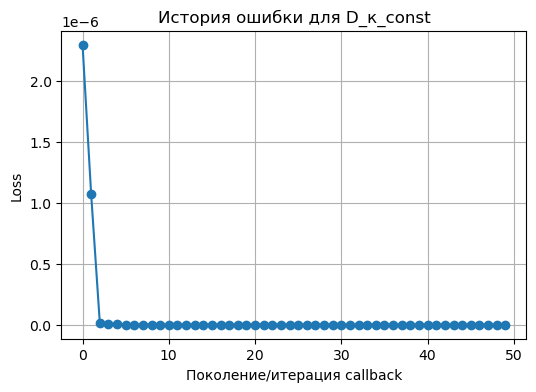

UnboundLocalError: cannot access local variable 'D_к' where it is not associated with a value

In [129]:
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# Словарь для хранения истории ошибок
history = {}

# ================================
# Оптимизация с сохранением истории
# ================================
best_results = {}
D_types = ['D_к_const', 'D_вт_const', 'D_ср_const']

for D_type in D_types:
    print(f"\n=== Запуск оптимизации для {D_type} ===")
    errors = []

    # колбэк для сохранения минимальной ошибки каждого поколения
    def callback(xk, convergence=0):
        err = loss(xk, D_type)
        errors.append(err)

    result = differential_evolution(
        lambda p: loss(p, D_type),
        bounds,
        strategy='best1bin',
        maxiter=50,
        popsize=10,
        tol=1e-3,
        polish=True,
        callback=callback
    )

    best_results[D_type] = result
    history[D_type] = errors
    print(f"Ошибка: {result.fun:.6f}")

# ================================
# Вывод лучших результатов + графики
# ================================
for D_type, result in best_results.items():
    best_params = result.x
    d1_отн, c_а1_отн, c_a2_отн, Hт_ср_отн, H_т1, R_ср1 = best_params
    η_best, π_best, η0_best, π0_best = model(best_params, D_type)

    print(f"\n--- Лучший результат для {D_type} ---")
    print(f"d1_отн = {d1_отн:.5f}")
    print(f"c_а1_отн = {c_а1_отн:.5f}")
    print(f"c_a2_отн = {c_a2_отн:.5f}")
    print(f"Hт_ср_отн = {Hт_ср_отн:.5f}")
    print(f"H_т1 = {H_т1:.5f}")
    print(f"R_ср1 = {R_ср1:.5f}")
    print(f"η = {η_best:.5f}")
    print(f"π = {π_best:.5f}")
    print(f"η0 = {η0_best:.5f}")
    print(f"π0 = {π0_best:.5f}")
    print(f"Ошибка = {result.fun:.6f}")

    # график истории ошибок
    plt.figure(figsize=(6,4))
    plt.plot(history[D_type], marker='o')
    plt.title(f"История ошибки для {D_type}")
    plt.xlabel("Поколение/итерация callback")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

In [ ]:
"""
# ================================
# Функция ошибки
# ================================
def loss(params, D_type):
    try:
        η, π, η0, π0 = model(params, D_type)  # модель возвращает 2 значения

        if not np.isfinite(η) or not np.isfinite(π):
            return 1e6
        if η <= 0 or π <= 1:
            return 1e6

        # нормированная ошибка относительно целевых η0 и π0
        err = ((η - η0)/η0)**2 + ((π - π0)/π0)**2
        return err

    except Exception:
        return 1e6


# ================================
# Оптимизация
# ================================
best_results = {}

for D_type in D_types:
    print(f"\n=== Запуск оптимизации для {D_type} ===")
    result = differential_evolution(
        lambda p: loss(p, D_type),
        bounds,
        strategy='best1bin',
        maxiter=50,
        popsize=10,
        tol=1e-3,
        polish=True
    )

    best_results[D_type] = result
    print(f"Ошибка: {result.fun:.6f}")

# ================================
# Вывод лучших результатов
# ================================
for D_type, result in best_results.items():
    best_params = result.x
    d1_отн, c_а1_отн, c_a2_отн, Hт_ср_отн, H_т1, R_ср1 = best_params
    η_best, π_best, η0_best, π0_best = model(best_params, D_type)

    print(f"\n--- Лучший результат для {D_type} ---")
    print(f"d1_отн = {d1_отн:.5f}")
    print(f"c_а1_отн = {c_а1_отн:.5f}")
    print(f"c_a2_отн = {c_a2_отн:.5f}")
    print(f"Hт_ср_отн = {Hт_ср_отн:.5f}")
    print(f"H_т1 = {H_т1:.5f}")
    print(f"R_ср1 = {R_ср1:.5f}")
    print(f"η = {η_best:.5f}")
    print(f"π = {π_best:.5f}")
    print(f"η = {η0_best:.5f}")
    print(f"π = {π0_best:.5f}")
    print(f"Ошибка = {result.fun:.6f}")
    """


=== Запуск оптимизации для D_к_const ===
Ошибка: 0.000000

=== Запуск оптимизации для D_вт_const ===


/var/folders/pt/n63d17nx4qv2jqtjp5hnm1wh0000gn/T/ipykernel_18109/3531455223.py:419: RuntimeWarning: invalid value encountered in sqrt
  D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))


Ошибка: 1000000.000000

=== Запуск оптимизации для D_ср_const ===
Ошибка: 1000000.000000

--- Лучший результат для D_к_const ---
d1_отн = 0.49734
c_а1_отн = 0.64817
c_a2_отн = 0.53886
Hт_ср_отн = 0.32521
H_т1 = 0.16603
R_ср1 = 0.11000
η = 0.83381
π = 18.20000
η = 0.83381
π = 18.20000
Ошибка = 0.000000


UnboundLocalError: cannot access local variable 'D_к' where it is not associated with a value